<a href="https://colab.research.google.com/github/Najwaalya/PCVK_Ganjil_2025/blob/main/Modul9_Morfologi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Persiapan Awal

In [1]:
# Hubungkan Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import library
import cv2
import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


## Fungsi Dilasi Manual (tanpa OpenCV morphology)

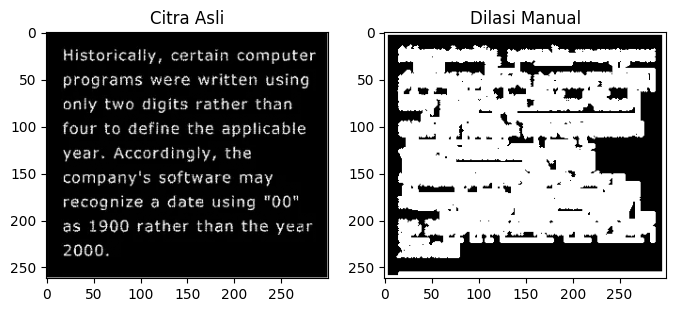

In [2]:
# Membaca citra
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/morphology.png', 0)  # ubah path sesuai lokasi file kamu

# Structuring Element Cross 3x3
kernel = np.array([[0,1,0],
                   [1,1,1],
                   [0,1,0]], dtype=np.uint8)

# Fungsi dilasi manual
def dilasi_manual(img, kernel):
    m, n = kernel.shape
    y, x = img.shape
    pad = m//2
    img_pad = np.pad(img, pad, mode='constant', constant_values=0)
    hasil = np.zeros_like(img)

    for i in range(y):
        for j in range(x):
            if np.max(kernel * img_pad[i:i+m, j:j+n]) > 0:
                hasil[i,j] = 255
    return hasil

hasil_dilasi = dilasi_manual(img, kernel)

# Tampilkan hasil
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Citra Asli')
plt.subplot(1,2,2); plt.imshow(hasil_dilasi, cmap='gray'); plt.title('Dilasi Manual')
plt.show()

## Dilasi dengan OpenCV

Structuring Element:
 [[0 1 0]
 [1 1 1]
 [0 1 0]]


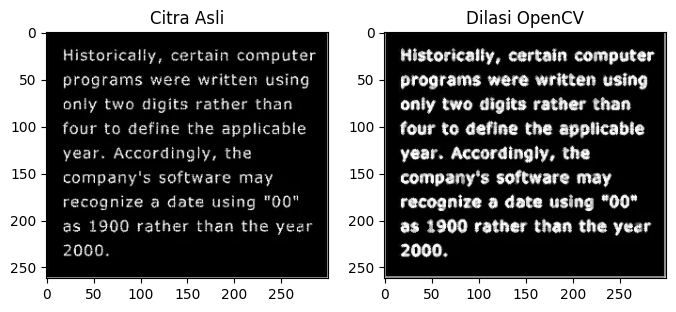

In [3]:
# Structuring Element cross 3x3
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
print("Structuring Element:\n", kernel)

hasil_dilasi_cv = cv2.dilate(img, kernel, iterations=1)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Citra Asli')
plt.subplot(1,2,2); plt.imshow(hasil_dilasi_cv, cmap='gray'); plt.title('Dilasi OpenCV')
plt.show()

## Fungsi Erosi Manual (tanpa OpenCV morphology)

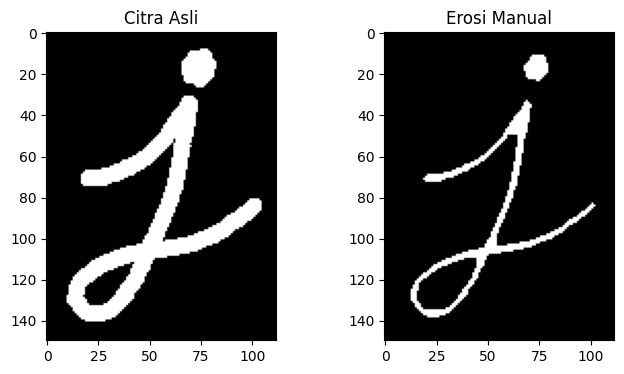

In [9]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/j.png', 0)

kernel = np.ones((5,5), np.uint8)

def erosi_manual(img, kernel):
    m, n = kernel.shape
    y, x = img.shape
    pad = m//2
    img_pad = np.pad(img, pad, mode='constant', constant_values=255)
    hasil = np.zeros_like(img)

    for i in range(y):
        for j in range(x):
            if np.min(img_pad[i:i+m, j:j+n][kernel==1]) == 255:
                hasil[i,j] = 255
    return hasil

hasil_erosi = erosi_manual(img, kernel)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Citra Asli')
plt.subplot(1,2,2); plt.imshow(hasil_erosi, cmap='gray'); plt.title('Erosi Manual')
plt.show()

## Erosi dengan OpenCV

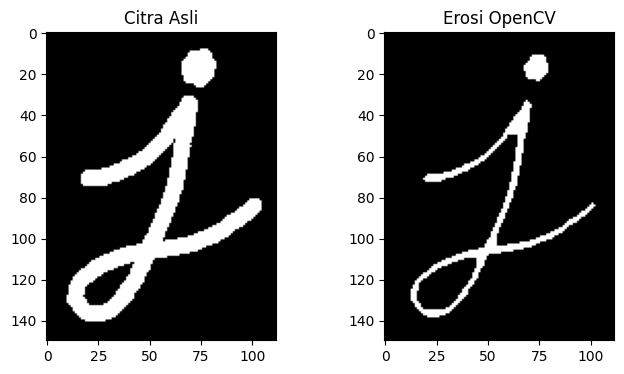

In [10]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
hasil_erosi_cv = cv2.erode(img, kernel, iterations=1)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Citra Asli')
plt.subplot(1,2,2); plt.imshow(hasil_erosi_cv, cmap='gray'); plt.title('Erosi OpenCV')
plt.show()

## Operasi Opening (tanpa dan dengan OpenCV)

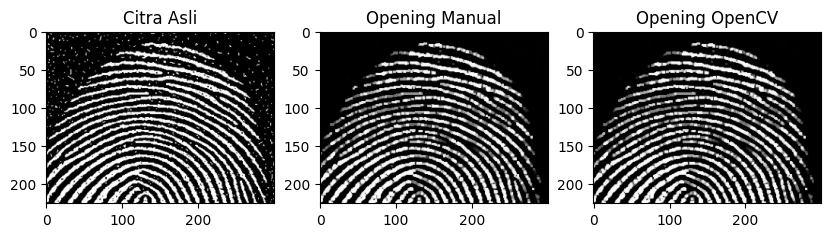

In [7]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/fingerprint.png', 0)
kernel = np.ones((3,3), np.uint8)

# Manual: erosi -> dilasi
hasil_opening_manual = cv2.dilate(cv2.erode(img, kernel), kernel)
hasil_opening_cv = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Citra Asli')
plt.subplot(1,3,2); plt.imshow(hasil_opening_manual, cmap='gray'); plt.title('Opening Manual')
plt.subplot(1,3,3); plt.imshow(hasil_opening_cv, cmap='gray'); plt.title('Opening OpenCV')
plt.show()

## Operasi Closing (tanpa dan dengan OpenCV)

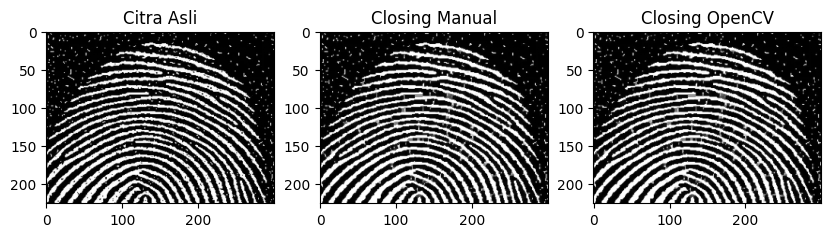

In [8]:
# Manual: dilasi -> erosi
hasil_closing_manual = cv2.erode(cv2.dilate(img, kernel), kernel)
hasil_closing_cv = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Citra Asli')
plt.subplot(1,3,2); plt.imshow(hasil_closing_manual, cmap='gray'); plt.title('Closing Manual')
plt.subplot(1,3,3); plt.imshow(hasil_closing_cv, cmap='gray'); plt.title('Closing OpenCV')
plt.show()

## Dilasi dengan Structuring Element Cross 3×3 & 5×5

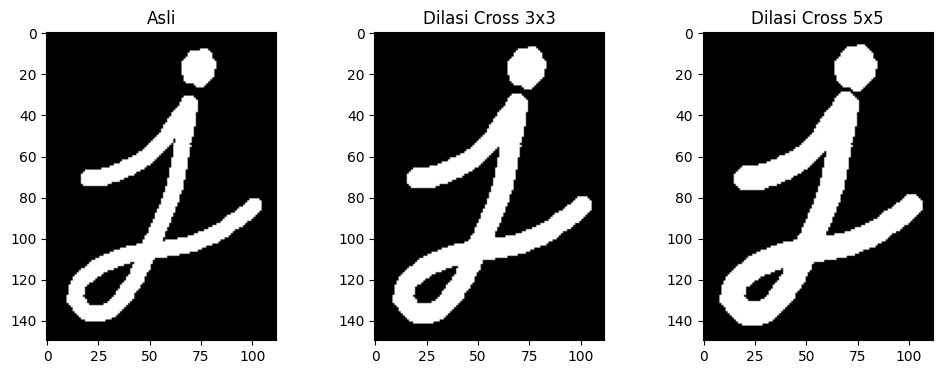

In [11]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/j.png', 0)

kernel1 = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
kernel2 = cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5))

hasil_dilasi_3 = cv2.dilate(img, kernel1)
hasil_dilasi_5 = cv2.dilate(img, kernel2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Asli')
plt.subplot(1,3,2); plt.imshow(hasil_dilasi_3, cmap='gray'); plt.title('Dilasi Cross 3x3')
plt.subplot(1,3,3); plt.imshow(hasil_dilasi_5, cmap='gray'); plt.title('Dilasi Cross 5x5')
plt.show()

## Dilasi dengan Structuring Element Circular 3×3 & 5×5

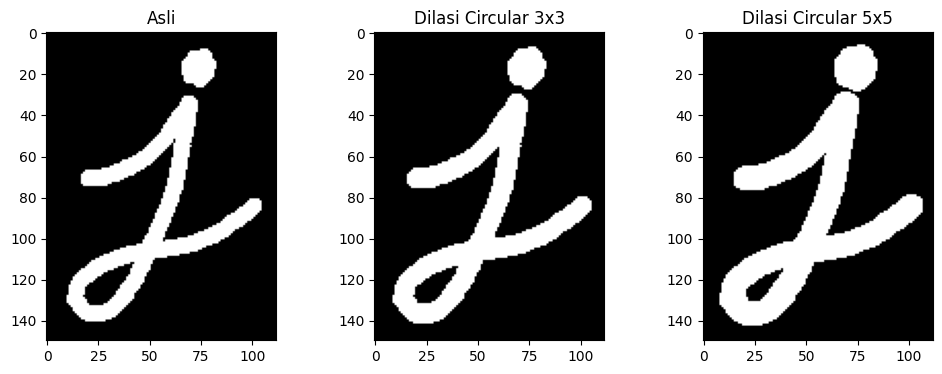

In [12]:
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

hasil_dilasi_c3 = cv2.dilate(img, kernel1)
hasil_dilasi_c5 = cv2.dilate(img, kernel2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Asli')
plt.subplot(1,3,2); plt.imshow(hasil_dilasi_c3, cmap='gray'); plt.title('Dilasi Circular 3x3')
plt.subplot(1,3,3); plt.imshow(hasil_dilasi_c5, cmap='gray'); plt.title('Dilasi Circular 5x5')
plt.show()

## Erosi dengan Structuring Element Rectangle 3×5 & 5×7

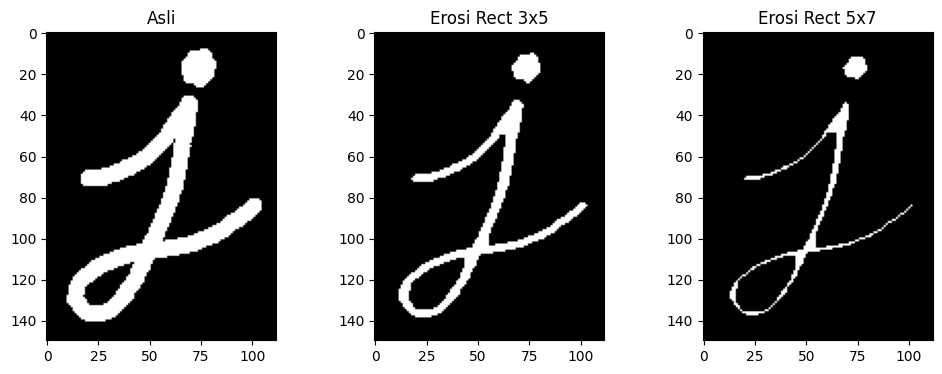

In [13]:
kernel1 = cv2.getStructuringElement(cv2.MORPH_RECT, (3,5))
kernel2 = cv2.getStructuringElement(cv2.MORPH_RECT, (5,7))

hasil_erosi_r1 = cv2.erode(img, kernel1)
hasil_erosi_r2 = cv2.erode(img, kernel2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Asli')
plt.subplot(1,3,2); plt.imshow(hasil_erosi_r1, cmap='gray'); plt.title('Erosi Rect 3x5')
plt.subplot(1,3,3); plt.imshow(hasil_erosi_r2, cmap='gray'); plt.title('Erosi Rect 5x7')
plt.show()

## Erosi dengan Structuring Element Line Vertikal 3 & 5

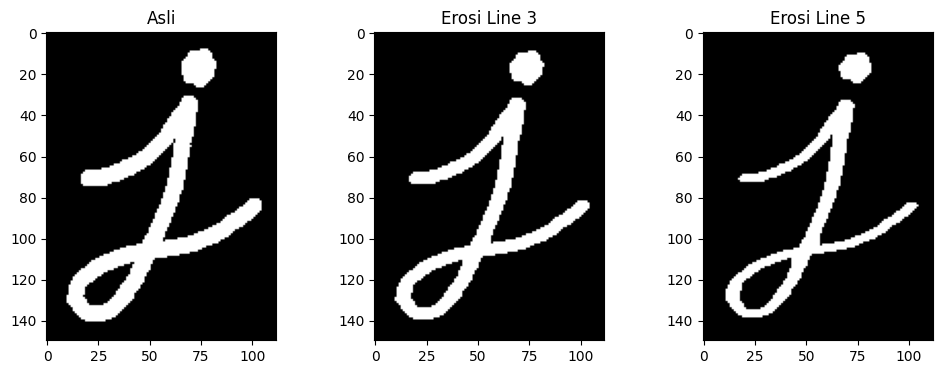

In [14]:
kernel1 = cv2.getStructuringElement(cv2.MORPH_RECT, (1,3))
kernel2 = cv2.getStructuringElement(cv2.MORPH_RECT, (1,5))

hasil_erosi_l3 = cv2.erode(img, kernel1)
hasil_erosi_l5 = cv2.erode(img, kernel2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Asli')
plt.subplot(1,3,2); plt.imshow(hasil_erosi_l3, cmap='gray'); plt.title('Erosi Line 3')
plt.subplot(1,3,3); plt.imshow(hasil_erosi_l5, cmap='gray'); plt.title('Erosi Line 5')
plt.show()